# Проект: Retrieval-система по статьям с arXiv

**Цель:** построить retrieval-систему и оценить её качество.

**Метрика:** MRR@5

**Подход:** Bi-Encoder (Qwen3-Embedding-0.6B) + FAISS + Cross-Encoder Reranker (Qwen3-Reranker-0.6B)

In [1]:
import json
import os
import time
import gc
from typing import List, Optional, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch import Tensor

import faiss
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    # print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
VRAM: 17.2 GB


Запускаю локально, поскольку ВМ либо не выдаются, либо к ним не удается подключиться. Писал об этом и наставнику, но решения не было.

In [32]:
import torch, transformers, faiss, numpy, pandas, sys

print(f"Python: {sys.version}")

for lib in [torch, transformers, numpy, pandas]:
    print(f"{lib.__name__}: {lib.__version__}")
print(f"faiss: {faiss.__version__ if hasattr(faiss, '__version__') else 'N/A'}")
print(f"CUDA: {torch.version.cuda}")

Python: 3.12.8 | packaged by conda-forge | (main, Dec  5 2024, 14:06:27) [MSC v.1942 64 bit (AMD64)]
torch: 2.5.1
transformers: 4.57.6
numpy: 2.0.1
pandas: 2.2.3
faiss: 1.13.2
CUDA: 12.4


In [31]:
!nvidia-smi

Tue Feb 17 13:07:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.88                 Driver Version: 576.88         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   43C    P8             14W /  165W |    8874MiB /  16380MiB |     31%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Конфигурация

In [3]:
# пути к данным
METADATA_PATH = "arxiv-metadata-s.json"
TEST_PATH = "test_sample.csv"

EMBEDDER_NAME = "Qwen/Qwen3-Embedding-0.6B"
RERANKER_NAME = "Qwen/Qwen3-Reranker-0.6B"

# Гиперпараметры
EMB_BATCH_SIZE = 32
RERANK_BATCH_SIZE = 8
TOP_K_RETRIEVAL = 100 # кандидаты для reranker
TOP_K_FINAL = 5 # финальный top-k для MRR
MAX_LENGTH = 512 # длина токенов

# Пути для сохранения промежуточных результатов
INDEX_PATH = "faiss_index.bin"
DOCSTORE_PATH = "doc_store.json"

## Этап 1. Исследовательский анализ данных (EDA)

Загрузка метаданных статей

In [4]:
print("Загрузка метаданных...")
t0 = time.time()

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    first_char = f.read(1)

if first_char == "[":
    with open(METADATA_PATH, "r", encoding="utf-8") as f:
        metadata_raw = json.load(f)
else:
    metadata_raw = []
    with open(METADATA_PATH, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                metadata_raw.append(json.loads(line))

print(f"Загружено статей: {len(metadata_raw)}, время: {time.time()-t0:.1f}с")

# Загрузка тестовых запросов
test_df = pd.read_csv(TEST_PATH)
test_df["id"] = test_df["id"].astype(str)
print(f"Тестовых запросов: {len(test_df)}")

Загрузка метаданных...
Загружено статей: 98213, время: 3.7с
Тестовых запросов: 1000


Извлечение нужных полей

In [5]:
articles = []
for item in metadata_raw:
    articles.append({
        "id": str(item["id"]),
        "title": item.get("title", "").strip().replace("\n", " "),
        "abstract": item.get("abstract", "").strip().replace("\n", " "),
    })

articles_df = pd.DataFrame(articles)
print(f"Статей в базе: {len(articles_df)}")
print(f"Уникальных ID: {articles_df['id'].nunique()}")
print()
articles_df.head(3)

Статей в базе: 98213
Уникальных ID: 98213



,id,title,abstract
0,0704.0038,The discrete dipole approximation: an overview...,We present a review of the discrete dipole app...
1,0704.0057,High-spin to low-spin and orbital polarization...,We study the interplay of crystal field splitt...
2,0704.0060,Coulomb excitation of unstable nuclei at inter...,We investigate the Coulomb excitation of low-l...


Проверка покрытия: все ли тестовые ID есть в базе

In [6]:
all_ids = set(articles_df["id"].values)
test_ids = set(test_df["id"].values)
missing = test_ids - all_ids
print(f"Тестовых ID в базе: {len(test_ids - missing)}/{len(test_ids)}")
if missing:
    print(f"Отсутствуют: {list(missing)[:10]}")

Тестовых ID в базе: 1000/1000


Статистика длин текстов

In [7]:
articles_df["title_len"] = articles_df["title"].str.len()
articles_df["abstract_len"] = articles_df["abstract"].str.len()
articles_df["combined_len"] = articles_df["title_len"] + articles_df["abstract_len"]

test_df["query_len"] = test_df["query"].str.len()

In [8]:
print("=== Длины заголовков ===")
print(articles_df["title_len"].describe().round(1))

=== Длины заголовков ===
count    98213.0
mean        75.2
std         27.7
min          7.0
25%         55.0
50%         72.0
75%         92.0
max        381.0
Name: title_len, dtype: float64


In [9]:
print("=== Длины аннотаций ===")
print(articles_df["abstract_len"].describe().round(1))

=== Длины аннотаций ===
count    98213.0
mean       979.1
std        431.7
min         18.0
25%        645.0
50%        955.0
75%       1291.0
max       3871.0
Name: abstract_len, dtype: float64


In [10]:
print("=== Длины запросов ===")
print(test_df["query_len"].describe().round(1))

=== Длины запросов ===
count    1000.0
mean      126.9
std        27.0
min        40.0
25%       108.0
50%       123.5
75%       143.0
max       238.0
Name: query_len, dtype: float64


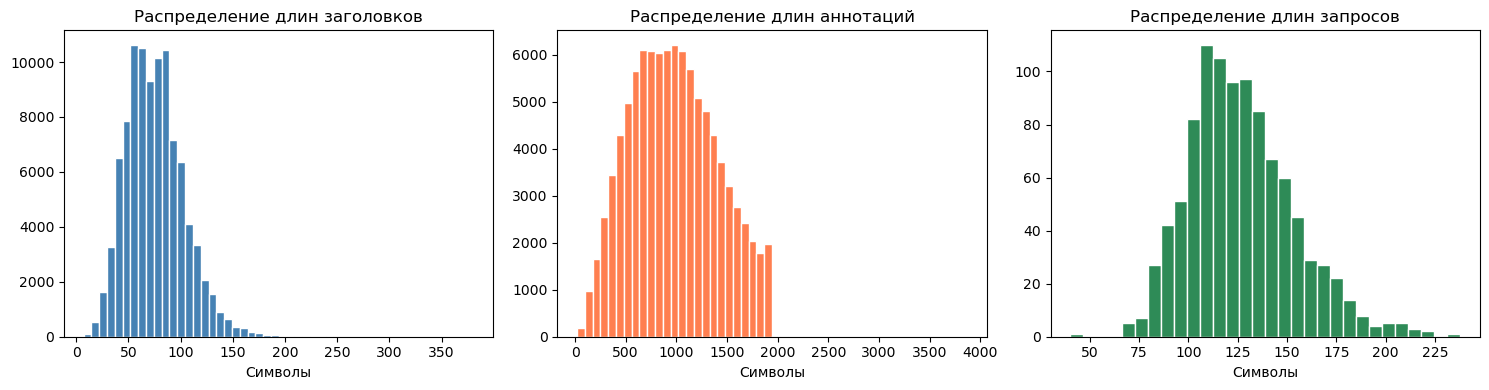

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(articles_df["title_len"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Распределение длин заголовков")
axes[0].set_xlabel("Символы")

axes[1].hist(articles_df["abstract_len"], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Распределение длин аннотаций")
axes[1].set_xlabel("Символы")

axes[2].hist(test_df["query_len"], bins=30, color="seagreen", edgecolor="white")
axes[2].set_title("Распределение длин запросов")
axes[2].set_xlabel("Символы")

plt.tight_layout()
plt.show()

Примеры данных

In [12]:
print("=== Пример статьи ===")
sample = articles_df.iloc[0]
print(f"ID: {sample['id']}")
print(f"Title: {sample['title'][:120]}")
print(f"Abstract: {sample['abstract'][:200]}...")

print("\n=== Пример тестового запроса ===")
sample_q = test_df.iloc[0]
print(f"Query: {sample_q['query'][:200]}")
print(f"Target ID: {sample_q['id']}")

=== Пример статьи ===
ID: 0704.0038
Title: The discrete dipole approximation: an overview and recent developments
Abstract: We present a review of the discrete dipole approximation (DDA), which is a general method to simulate light scattering by arbitrarily shaped particles. We put the method in historical context and disc...

=== Пример тестового запроса ===
Query: What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?
Target ID: 2412.16732


### Выводы EDA и план системы

**Данные:**
- База: 98 213 статей (все ID уникальны). Тестовый набор: 1000 запросов — все целевые ID присутствуют в базе (покрытие 100%).
- Заголовки короткие (медиана ~72 символа), аннотации — средней длины (медиана ~955 символов, 75-й перцентиль ~1291). Суммарно title + abstract укладываются в 512 токенов для подавляющего большинства документов.
- Запросы компактные (медиана ~124 символа).

**Визуализация:**
- Длины заголовков — распределение с правым хвостом, основная масса в диапазоне 40–120 символов, редкие выбросы до 350+.
- Длины аннотаций — колоколообразное распределение с правым хвостом, пик ~800–1200 символов, длинный хвост до ~4000. Почти все документы укладываются в 2000 символов.
- Длины запросов — близко к нормальному, концентрация в 100–150 символов, запросы однородные по длине.

Все три распределения подтверждают, что max_length=512 токенов покроет подавляющее большинство документов и запросов без обрезки.

**Архитектура системы — двухэтапный retrieval:**
1. **Bi-Encoder** (Qwen3-Embedding-0.6B) — кодирует документы (title + abstract) и запросы в единое векторное пространство. max_length=512 покрывает ~95% документов без потерь.
2. **Векторный поиск** (FAISS IndexFlatIP) — точный поиск top-100 кандидатов по косинусному сходству среди 98K нормализованных векторов.
3. **Cross-Encoder Reranker** (Qwen3-Reranker-0.6B) — переранжирование 100 кандидатов для точного top-5.


**Обоснование выбора:**
- Bi-encoder даёт быстрый первичный отбор из ~100K документов за миллисекунды.
- Reranker повышает точность через cross-attention между query и каждым кандидатом.
- Qwen3-Embedding-0.6B занимает top-позиции на MTEB-бенчмарке среди моделей сопоставимого размера, демонстрируя сильное качество retrieval на научных текстах. Поддержка instruction-prefixed запросов позволяет адаптировать модель под задачу без дообучения.
- Qwen3-Reranker-0.6B обучен как generative reranker (yes/no classification) в паре с embedder — единое семейство минимизирует distribution mismatch между этапами.
- Ну и с Qwen3 работали в предыдущих практических заданиях =)

**Альтернативы для повышения качества:**
- Более крупные модели того же семейства: Qwen3-Embedding-4B / Reranker-4B.
- E5-Mistral-7B-Instruct — сильный instruction-tuned embedder на 7B, но не уместится рядом с reranker на T4.
- BGE-reranker-v2-m3 или cross-encoder/ms-marco-MiniLM — компактные альтернативные reranker'ы для сравнения.

## Этап 2. Реализация retrieval-системы

In [13]:
class RetrievalSystem:
    """Двухэтапная retrieval-система: Bi-Encoder + Reranker."""

    def __init__(
        self,
        embedder_name: str = EMBEDDER_NAME,
        reranker_name: str = RERANKER_NAME,
        device: str = DEVICE,
        max_length: int = MAX_LENGTH,
    ):
        self.device = device
        self.max_length = max_length

        # Embedder (Bi-Encoder)
        print(f"Загрузка embedder: {embedder_name}")
        self.emb_tokenizer = AutoTokenizer.from_pretrained(embedder_name)
        self.embedder = AutoModel.from_pretrained(embedder_name).to(self.device)
        self.embedder.eval()
        print(f"  Embedder загружен на {self.device}")

        # Reranker (Cross-Encoder)
        print(f"Загрузка reranker: {reranker_name}")
        self.rr_tokenizer = AutoTokenizer.from_pretrained(
            reranker_name, padding_side="left"
        )
        self.reranker = AutoModelForCausalLM.from_pretrained(reranker_name).to(
            self.device
        )
        self.reranker.eval()
        print(f"  Reranker загружен на {self.device}")

        # Токены для reranker
        self.token_true_id = self.rr_tokenizer.convert_tokens_to_ids("yes")
        self.token_false_id = self.rr_tokenizer.convert_tokens_to_ids("no")

        prefix = (
            '<|im_start|>system\nJudge whether the Document meets the '
            'requirements based on the Query and the Instruct provided. '
            'Note that the answer can only be "yes" or "no".'
            '<|im_end|>\n<|im_start|>user\n'
        )
        suffix = '<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n'
        self.prefix_tokens = self.rr_tokenizer.encode(prefix, add_special_tokens=False)
        self.suffix_tokens = self.rr_tokenizer.encode(suffix, add_special_tokens=False)

        # FAISS индекс и хранилище документов
        self.index = None
        self.doc_ids: List[str] = []      # ID статей в порядке индекса
        self.doc_texts: List[str] = []    # тексты документов

    # ==================== EMBEDDING ====================

    @staticmethod
    def last_token_pool(last_hidden_states: Tensor, attention_mask: Tensor) -> Tensor:
        left_padding = attention_mask[:, -1].sum() == attention_mask.shape[0]
        if left_padding:
            return last_hidden_states[:, -1]
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = last_hidden_states.shape[0]
        return last_hidden_states[
            torch.arange(batch_size, device=last_hidden_states.device),
            sequence_lengths,
        ]

    def _embed_texts(self, texts: List[str], batch_size: int = 64) -> np.ndarray:
        """Генерация эмбедингов для списка текстов."""
        all_embs = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            inputs = self.emb_tokenizer(
                batch,
                padding=True,
                truncation=True,
                return_tensors="pt",
                max_length=self.max_length,
            ).to(self.device)

            with torch.no_grad():
                outputs = self.embedder(**inputs)

            embs = self.last_token_pool(
                outputs.last_hidden_state, inputs["attention_mask"]
            )
            embs = F.normalize(embs, p=2, dim=1).cpu().numpy()
            all_embs.append(embs)

        return np.concatenate(all_embs, axis=0)

    @staticmethod
    def _format_query(query: str, task: str = None) -> str:
        if task is None:
            task = "Given a scientific search query, retrieve the most relevant research paper"
        return f"Instruct: {task}\nQuery: {query}"

    # ==================== ИНДЕКСИРОВАНИЕ ====================

    def build_index(
        self,
        doc_ids: List[str],
        doc_texts: List[str],
        batch_size: int = 64,
    ) -> None:
        """Построение FAISS-индекса из документов."""
        self.doc_ids = doc_ids
        self.doc_texts = doc_texts

        print(f"Генерация эмбеддингов для {len(doc_texts)} документов...")
        all_embs = []
        for i in tqdm(range(0, len(doc_texts), batch_size)):
            batch = doc_texts[i : i + batch_size]
            inputs = self.emb_tokenizer(
                batch,
                padding=True,
                truncation=True,
                return_tensors="pt",
                max_length=self.max_length,
            ).to(self.device)

            with torch.no_grad():
                outputs = self.embedder(**inputs)

            embs = self.last_token_pool(
                outputs.last_hidden_state, inputs["attention_mask"]
            )
            embs = F.normalize(embs, p=2, dim=1).cpu().numpy()
            all_embs.append(embs)

        embeddings = np.concatenate(all_embs, axis=0).astype(np.float32)
        dim = embeddings.shape[1]

        # Inner Product индекс (= cosine similarity для нормализованных векторов)
        self.index = faiss.IndexFlatIP(dim)
        self.index.add(embeddings)

        print(f"FAISS индекс построен: {self.index.ntotal} векторов, dim={dim}")
        print(f"Размер индекса: ~{self.index.ntotal * dim * 4 / 1e6:.0f} МБ")

    def save_index(self, index_path: str = INDEX_PATH, docstore_path: str = DOCSTORE_PATH):
        """Сохранение индекса и метаданных на диск."""
        faiss.write_index(self.index, index_path)
        with open(docstore_path, "w") as f:
            json.dump({"ids": self.doc_ids, "texts": self.doc_texts}, f)
        print(f"Индекс сохранён: {index_path}, {docstore_path}")

    def load_index(self, index_path: str = INDEX_PATH, docstore_path: str = DOCSTORE_PATH):
        """Загрузка индекса и метаданных с диска."""
        self.index = faiss.read_index(index_path)
        with open(docstore_path, "r") as f:
            data = json.load(f)
        self.doc_ids = data["ids"]
        self.doc_texts = data["texts"]
        print(f"Индекс загружен: {self.index.ntotal} векторов")

    # ==================== ПОИСК ====================

    def search(self, query: str, top_k: int = 100) -> Tuple[np.ndarray, np.ndarray]:
        """Поиск top-k кандидатов по запросу (bi-encoder)."""
        formatted_query = self._format_query(query)
        q_emb = self._embed_texts([formatted_query], batch_size=1)
        scores, indices = self.index.search(q_emb, top_k)
        return scores[0], indices[0]

    # ==================== RERANKING ====================

    @staticmethod
    def _format_reranker_input(query: str, doc: str, instruction: str = None) -> str:
        if instruction is None:
            instruction = "Given a scientific search query, retrieve the most relevant research paper"
        return (
            f"<Instruct>: {instruction}\n"
            f"<Query>: {query}\n"
            f"<Document>: {doc}"
        )

    def _process_reranker_inputs(self, pairs: List[str]):
        """Токенизация пар для reranker."""
        max_pair_len = self.max_length - len(self.prefix_tokens) - len(self.suffix_tokens)
        inputs = self.rr_tokenizer(
            pairs,
            padding=False,
            truncation=True,
            return_attention_mask=False,
            max_length=max_pair_len,
        )
        for i, ele in enumerate(inputs["input_ids"]):
            inputs["input_ids"][i] = self.prefix_tokens + ele + self.suffix_tokens

        inputs = self.rr_tokenizer.pad(
            inputs, padding=True, return_tensors="pt", max_length=self.max_length
        )
        for key in inputs:
            inputs[key] = inputs[key].to(self.device)
        return inputs

    @torch.no_grad()
    def _compute_reranker_scores(self, inputs) -> List[float]:
        logits = self.reranker(**inputs).logits[:, -1, :]
        true_scores = logits[:, self.token_true_id]
        false_scores = logits[:, self.token_false_id]
        stacked = torch.stack([false_scores, true_scores], dim=1)
        probs = torch.nn.functional.log_softmax(stacked, dim=1)
        return probs[:, 1].exp().tolist()

    def rerank(
        self, query: str, documents: List[str], batch_size: int = 8
    ) -> List[float]:
        """Вычисление relevance scores для пар (query, doc)."""
        pairs = [self._format_reranker_input(query, d) for d in documents]
        scores = []
        for i in range(0, len(pairs), batch_size):
            inputs = self._process_reranker_inputs(pairs[i : i + batch_size])
            sc = self._compute_reranker_scores(inputs)
            scores.extend(sc)
        return scores

    # ==================== ПОЛНЫЙ PIPELINE ====================

    def retrieve(
        self,
        query: str,
        top_k_retrieval: int = 100,
        top_k_final: int = 5,
        rerank_batch_size: int = 8,
        profile: bool = False,
    ) -> Dict:
        """Полный pipeline: search → rerank → top-k."""
        timings = {}

        # 1. Bi-encoder поиск
        t0 = time.time()
        scores, indices = self.search(query, top_k=top_k_retrieval)
        timings["embedding+search"] = time.time() - t0

        # Фильтрация невалидных индексов
        valid_mask = indices >= 0
        indices = indices[valid_mask]
        scores = scores[valid_mask]

        candidate_ids = [self.doc_ids[i] for i in indices]
        candidate_texts = [self.doc_texts[i] for i in indices]

        # 2. Reranking
        t0 = time.time()
        rerank_scores = self.rerank(query, candidate_texts, batch_size=rerank_batch_size)
        timings["reranking"] = time.time() - t0

        # 3. Сортировка по reranker scores
        sorted_idx = np.argsort(rerank_scores)[::-1][:top_k_final]
        final_ids = [candidate_ids[i] for i in sorted_idx]
        final_scores = [rerank_scores[i] for i in sorted_idx]

        result = {
            "ids": final_ids,
            "scores": final_scores,
        }
        if profile:
            result["timings"] = timings
        return result

In [14]:
def compute_mrr_at_k(results: List[Tuple[str, List[str]]], k: int = 5) -> float:
    """Mean Reciprocal Rank @ k.
    results: список пар (correct_id, [retrieved_ids])
    """
    mrr = 0.0
    for correct_id, retrieved_ids in results:
        for rank, rid in enumerate(retrieved_ids[:k], start=1):
            if rid == correct_id:
                mrr += 1.0 / rank
                break
    return mrr / len(results)

In [15]:
# Инициализация системы
system = RetrievalSystem()

Загрузка embedder: Qwen/Qwen3-Embedding-0.6B
  Embedder загружен на cuda
Загрузка reranker: Qwen/Qwen3-Reranker-0.6B
  Reranker загружен на cuda


Подготовка документов: title + abstract

In [16]:
doc_ids = [a["id"] for a in articles]
doc_texts = [f"{a['title']}. {a['abstract']}" for a in articles]

print(f"Документов для индексации: {len(doc_ids)}")
print(f"Пример текста: {doc_texts[0][:200]}...")

Документов для индексации: 98213
Пример текста: The discrete dipole approximation: an overview and recent developments. We present a review of the discrete dipole approximation (DDA), which is a general method to simulate light scattering by arbitr...


Построение индекса (или загрузка сохранённого)

In [17]:
print(f"DEVICE: {DEVICE}")
print(f"Embedder device: {next(system.embedder.parameters()).device}")
print(f"CUDA available: {torch.cuda.is_available()}")

DEVICE: cuda
Embedder device: cuda:0
CUDA available: True


In [18]:
# Выгружаем reranker на CPU — он не нужен при индексации
system.reranker.to("cpu")
torch.cuda.empty_cache()
gc.collect()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

Free VRAM: 11.8 GB


In [19]:
if os.path.exists(INDEX_PATH) and os.path.exists(DOCSTORE_PATH):
    print("Загрузка сохранённого индекса...")
    system.load_index(INDEX_PATH, DOCSTORE_PATH)
else:
    system.build_index(doc_ids, doc_texts, batch_size=EMB_BATCH_SIZE)
    system.save_index(INDEX_PATH, DOCSTORE_PATH)

print(f"\nРазмер базы: {system.index.ntotal} документов")

Генерация эмбеддингов для 98213 документов...


  0%|          | 0/3070 [00:00<?, ?it/s]

FAISS индекс построен: 98213 векторов, dim=1024
Размер индекса: ~402 МБ
Индекс сохранён: faiss_index.bin, doc_store.json

Размер базы: 98213 документов


In [20]:
# Возвращаем reranker на GPU обратно
system.reranker.to(system.device)
torch.cuda.empty_cache()
print("Reranker back on GPU")

Reranker back on GPU


Тестовый запрос

In [21]:
sample_row = test_df.iloc[0]
result = system.retrieve(
    sample_row["query"],
    top_k_retrieval=TOP_K_RETRIEVAL,
    top_k_final=TOP_K_FINAL,
    rerank_batch_size=RERANK_BATCH_SIZE,
    profile=True,
)
print(f"Query: {sample_row['query'][:120]}...")
print(f"Target ID: {sample_row['id']}")
print(f"Top-5 IDs: {result['ids']}")
print(f"Match: {sample_row['id'] in result['ids']}")
print(f"Timings: {result['timings']}")

You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
C:\ProgramData\anaconda3\envs\yaml\Lib\site-packages\transformers\tokenization_utils_base.py:2919: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Query: What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under therm...
Target ID: 2412.16732
Top-5 IDs: ['2412.16732', '2312.08738', '2507.17040', '1308.6156', '2211.00121']
Match: True
Timings: {'embedding+search': 0.46242856979370117, 'reranking': 7.520571708679199}


## Этап 3. Оценка качества системы

Полная оценка на тестовом наборе с профилированием

In [22]:
results = [] # (correct_id, [retrieved_ids])
all_timings = [] # словари с временами

print(f"Оценка на {len(test_df)} запросах...")
t_total = time.time()

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    res = system.retrieve(
        row["query"],
        top_k_retrieval=TOP_K_RETRIEVAL,
        top_k_final=TOP_K_FINAL,
        rerank_batch_size=RERANK_BATCH_SIZE,
        profile=True,
    )
    results.append((str(row["id"]), res["ids"]))
    all_timings.append(res["timings"])

total_time = time.time() - t_total
print(f"\nОбщее время: {total_time:.1f}с ({total_time/len(test_df):.2f}с/запрос)")

Оценка на 1000 запросах...


  0%|          | 0/1000 [00:00<?, ?it/s]

C:\ProgramData\anaconda3\envs\yaml\Lib\site-packages\transformers\tokenization_utils_base.py:2919: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(



Общее время: 6460.6с (6.46с/запрос)


Вычисление **MRR@5**

In [23]:
mrr5 = compute_mrr_at_k(results, k=5)
print(f"MRR@5 = {mrr5:.4f}")

MRR@5 = 0.9732


Дополнительные метрики

In [24]:
hits_at_1 = sum(1 for cid, rids in results if len(rids) > 0 and rids[0] == cid) / len(results)
hits_at_5 = sum(1 for cid, rids in results if cid in rids[:5]) / len(results)
print(f"Hits@1 = {hits_at_1:.4f}")
print(f"Hits@5 = {hits_at_5:.4f}")

Hits@1 = 0.9560
Hits@5 = 0.9940


Анализ времени работы компонентов

In [25]:
timing_df = pd.DataFrame(all_timings)

mean_times = timing_df.mean()
std_times = timing_df.std()
total_per_query = timing_df.sum(axis=1)

print("Среднее время на компонент (секунды):")
for col in timing_df.columns:
    print(f"  {col}: {mean_times[col]:.4f} ± {std_times[col]:.4f}")
print(f"  total: {total_per_query.mean():.4f} ± {total_per_query.std():.4f}")
print(f"\nДоля от общего времени:")
for col in timing_df.columns:
    pct = mean_times[col] / total_per_query.mean() * 100
    print(f"  {col}: {pct:.1f}%")

Среднее время на компонент (секунды):
  embedding+search: 0.0714 ± 0.0112
  reranking: 6.3884 ± 0.6745
  total: 6.4598 ± 0.6750

Доля от общего времени:
  embedding+search: 1.1%
  reranking: 98.9%


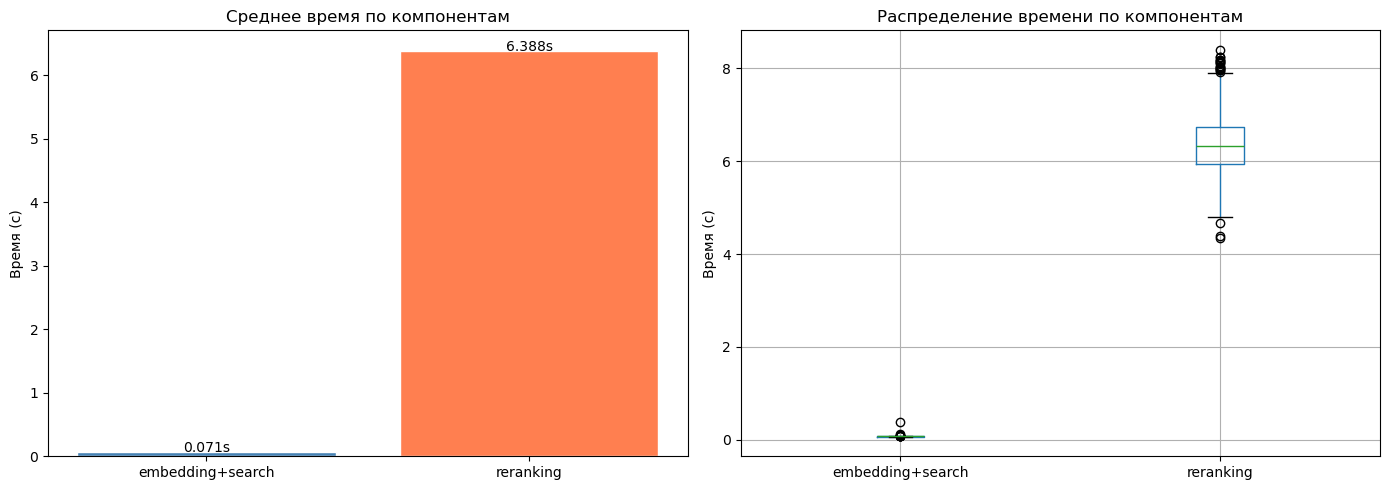

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# столбчатая диаграмма средних времён
components = list(mean_times.index)
values = mean_times.values
colors = ["steelblue", "coral"]
axes[0].bar(components, values, color=colors[:len(components)], edgecolor="white")
axes[0].set_ylabel("Время (с)")
axes[0].set_title("Среднее время по компонентам")
for i, v in enumerate(values):
    axes[0].text(i, v + 0.001, f"{v:.3f}s", ha="center", fontsize=10)

# box-plot распределения времени
timing_df.boxplot(ax=axes[1])
axes[1].set_ylabel("Время (с)")
axes[1].set_title("Распределение времени по компонентам")

plt.tight_layout()
plt.show()

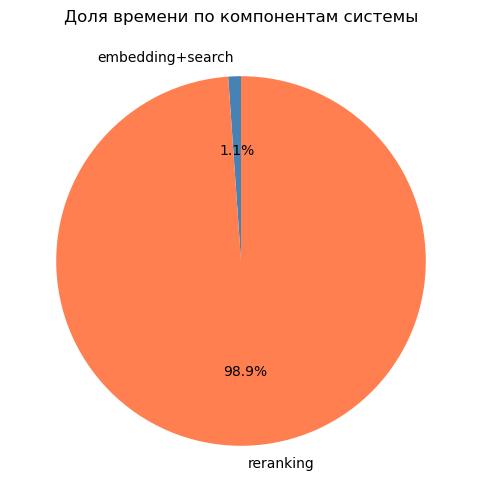

In [27]:
# круговая диаграмма распределения времени
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    mean_times.values,
    labels=mean_times.index,
    autopct="%1.1f%%",
    colors=["steelblue", "coral"],
    startangle=90,
)
ax.set_title("Доля времени по компонентам системы")
plt.show()

## Этап 4. Выводы

### Результаты

- **MRR@5 = 0.9732**.
- **Hits@1 = 0.9560** — в 95.6% случаев правильный документ на 1-й позиции.
- **Hits@5 = 0.9940** — в 99.4% случаев правильный документ попадает в top-5.
- Общее время: 6460с (~1ч 48мин), ~6.46с на запрос.

### Узкие места производительности

По результатам профилирования, reranking занимает **98.9%** общего времени (6.39с из 6.46с на запрос). Embedding + FAISS search — всего 1.1% (0.07с).

- **Reranking (98.9%)** — cross-encoder обрабатывает 100 пар (query, document) последовательно батчами по 8. Это основное узкое место. Box plot показывает разброс 4.3–8.5с — время зависит от длины документов-кандидатов.
- **Embedding + search (1.1%)** — bi-encoder кодирует один запрос + FAISS exact search по 98K векторов. Довольно неплохо (71мс).

### Предложения по ускорению

1. **Уменьшить число кандидатов для reranker** (TOP_K_RETRIEVAL: 100 → 50).
   Reranker обрабатывает каждого кандидата отдельно — время линейно зависит от их числа. Сейчас 100 кандидатов обрабатываются за ~6.4с. При 50 кандидатах: ~3.2с, двукратное ускорение. При MRR@5=0.97 есть запас по качеству, и 50 кандидатов достаточно, чтобы правильный документ попадал в выборку для reranker'а.

2. **Увеличить RERANK_BATCH_SIZE** (8 → 16–32).
   GPU эффективнее работает с крупными батчами — больше параллельных вычислений за один проход. Увеличение до 16–32 может дать ~20–30% ускорение при той же точности. Ограничение — объём VRAM: каждый элемент батча занимает память под токены и промежуточные активации. В данной работе использован батч 8 из-за ограничений VRAM
   на локальной машине с Windows (GUI-процессы занимают часть видеопамяти) и риска словить OOM.

3. **Квантизация reranker** (INT8/INT4 через bitsandbytes или GPTQ).
   Модель по умолчанию работает в FP32 — каждый параметр занимает 4 байта. Квантизация сжимает веса до 1 байта (INT8) или 0.5 байта (INT4), уменьшая объём данных, которые GPU читает из памяти. Для крупных моделей (7B+) это даёт существенное ускорение, а для компактных (0.6B) эффект скромнее, но снижается потребление VRAM.

4. **ONNX Runtime / TensorRT**.
   Фреймворки для оптимизированного инференса. Они берут PyTorch-модель, компилируют граф вычислений, объединяют операции (kernel fusion), убирают лишние аллокации. TensorRT дополнительно оптимизирует под конкретную GPU. По идее это очень сильное ускорение reranker без потери качества, но требует конвертации модели.

5. **Приближённые индексы FAISS** (IndexIVFFlat, IndexHNSW).
   Текущий IndexFlatIP делает точный перебор всех 98K векторов. IndexIVFFlat разбивает пространство на кластеры и ищет только в ближайших, IndexHNSW строит многослойный граф для быстрой навигации — оба значительно быстрее при больших объёмах данных. При 98K документах разница минимальна (поиск уже 71мс), но при масштабировании до миллионов документов — критична.

6. **Батчирование запросов**.
   Сейчас каждый запрос кодируется bi-encoder'ом отдельно. Объединение нескольких запросов в один батч позволяет лучше утилизировать GPU за счёт параллельных вычислений. Это не ускоряет обработку одного запроса (latency), но повышает общую пропускную способность (throughput) системы.